
# Baseline Evaluation: Graph + Node Classification

Notebook này được rút gọn và tổ chức lại để đánh giá **từng mô hình baseline** một cách rõ ràng.

## Mục tiêu
- Tách riêng **hàm dùng chung**
- Tách riêng từng baseline bằng **Markdown section**
- Mỗi baseline dùng **2 checkpoint riêng**:
  - `graph_ckpt`: checkpoint tốt nhất cho graph/window classification
  - `node_ckpt`: checkpoint tốt nhất cho node classification
- Tránh lỗi do biến đè lên nhau bằng cách dùng **config / result dict riêng** cho từng mô hình

## Các baseline mặc định
1. **MRGAT + KAN FFN + MLP Head**
2. **MRGAT + MLP FFN + KAN Head**
3. **MRGAT + MLP FFN + MLP Head**

Bạn chỉ cần cập nhật đường dẫn checkpoint trong cell cấu hình.


In [1]:

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append('../')
print(sys.path[-3:])


['', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/site-packages', '../']


In [2]:

import os
import inspect
import importlib
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
)
from sklearn.manifold import TSNE

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
sns.set_context("notebook")


## 1. Shared configuration

In [3]:

PROJECT_ROOT = Path('..').resolve()
GRAPH_FOLDER = PROJECT_ROOT / 'data/2017-subaru-forester/graphs_subsample_node_classification_v2'
SPLIT = 'test'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

BATCH_SIZE = 128
NUM_WORKERS = 8
MAX_SHARDS = 0       # 0 = all
MAX_SAMPLES = 0      # 0 = all

TSNE_MAX_POINTS = 3000
TSNE_PERPLEXITY = 30
TSNE_RANDOM_STATE = 42
SHOW_TSNE = True
SHOW_MISCLASSIFIED = True
MISCLASSIFIED_TOP_N = 20

print('GRAPH_FOLDER:', GRAPH_FOLDER)
print('DEVICE      :', DEVICE)
print('graph exists:', GRAPH_FOLDER.exists())


GRAPH_FOLDER: /home/hieutt/MRGA-KAN/data/2017-subaru-forester/graphs_subsample_node_classification_v2
DEVICE      : cuda
graph exists: True


## 2. Shared helpers

In [4]:

def load_table(base: Path) -> pd.DataFrame:
    pq = base.with_suffix('.parquet')
    csv = base.with_suffix('.csv')
    if pq.exists():
        return pd.read_parquet(pq)
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f'Cannot find {pq} or {csv}')


def infer_label_mapping(graph_folder: Path) -> Dict[int, str]:
    mapping = {}
    for split in ['train', 'val', 'test']:
        try:
            df = load_table(graph_folder / f'graph_index_{split}')
            if 'y' in df.columns and 'window_label' in df.columns:
                pairs = df[['y', 'window_label']].drop_duplicates()
                for _, row in pairs.iterrows():
                    mapping[int(row['y'])] = str(row['window_label'])
        except Exception:
            continue
    if not mapping:
        raise RuntimeError('Could not infer label mapping from graph_index files.')
    return dict(sorted(mapping.items(), key=lambda kv: kv[0]))


def graph_dict_to_data(graph: dict, fallback_graph_id: Optional[str] = None) -> Data:
    data = Data(
        x=graph['x'].float(),
        edge_index=graph['edge_index'].long(),
        edge_attr=graph['edge_attr'].float(),
        edge_type=graph['edge_type'].long(),
        id_token=graph['id_index'].long(),
        y=graph['y'].view(-1).long(),
    )

    if 'node_y' in graph:
        data.node_y = graph['node_y'].long()
    if 'node_mask' in graph:
        data.node_mask = graph['node_mask'].bool()
    if 'node_is_attack' in graph:
        data.node_is_attack = graph['node_is_attack'].long()

    meta = graph.get('meta', {})
    data.attack_count = torch.tensor([int(meta.get('attack_count', 0))], dtype=torch.long)
    data.attack_ratio = torch.tensor([float(meta.get('attack_ratio', 0.0))], dtype=torch.float32)
    data.is_mixed_window = torch.tensor([int(bool(meta.get('is_mixed_window', False)))], dtype=torch.long)

    graph_id = graph.get('graph_id', fallback_graph_id if fallback_graph_id is not None else 'unknown_graph')
    label_name = graph.get('window_label', None)
    data.graph_id = graph_id
    data.window_label = label_name if label_name is not None else None
    return data


def load_graph_split(graph_folder: Path, split_name: str, max_shards: int = 0, max_samples: int = 0) -> List[Data]:
    split_dir = graph_folder / split_name
    shard_paths = sorted(split_dir.glob(f'graphs_{split_name}_shard*.pt'))
    if len(shard_paths) == 0:
        raise FileNotFoundError(f'No shard files found in {split_dir}')
    if max_shards > 0:
        shard_paths = shard_paths[:max_shards]

    dataset: List[Data] = []
    count = 0
    for shard_path in shard_paths:
        shard_graphs = torch.load(shard_path, map_location='cpu', weights_only=False)
        for i, g in enumerate(shard_graphs):
            fallback_graph_id = f'{split_name}:{shard_path.stem}:{i}'
            dataset.append(graph_dict_to_data(g, fallback_graph_id=fallback_graph_id))
            count += 1
            if max_samples > 0 and count >= max_samples:
                return dataset
    return dataset


def get_node_target_and_mapping(node_target: str, graph_label_mapping: Dict[int, str]):
    if node_target == 'node_is_attack':
        return {0: 'normal', 1: 'attack'}, 2
    return graph_label_mapping.copy(), len(graph_label_mapping)


def get_num_ids(dataset: List[Data]) -> int:
    num_ids = 0
    for d in dataset:
        num_ids = max(num_ids, int(d.id_token.max().item()))
    return int(num_ids) + 1


def resolve_model_class(module_path: str):
    module = importlib.import_module(module_path)
    if not hasattr(module, 'GraphAttentionKAN'):
        raise ImportError(f'Module {module_path} does not define GraphAttentionKAN')
    return module.GraphAttentionKAN


def filter_kwargs_for_class(cls, kwargs: Dict[str, Any]) -> Dict[str, Any]:
    sig = inspect.signature(cls.__init__)
    valid = {}
    for k, v in kwargs.items():
        if k in sig.parameters:
            valid[k] = v
    return valid


def build_model_from_ckpt(model_cls, ckpt: dict, num_classes: int, num_node_classes: int, num_ids: int, sample_data: Data, device: str = 'cpu'):
    args = ckpt.get('args', {})
    candidate_kwargs = {
        'node_feat_dim': sample_data.x.size(1),
        'edge_attr_dim': sample_data.edge_attr.size(1),
        'num_classes': num_classes,
        'num_node_classes': num_node_classes,
        'num_ids': num_ids,
        'hidden_dim': args.get('hidden_dim', 128),
        'num_layers': args.get('num_layers', 3),
        'heads': args.get('heads', 2),
        'id_emb_dim': args.get('id_emb_dim', 32),
        'rel_emb_dim': args.get('rel_emb_dim', 8),
        'num_relations': args.get('num_relations', 4),
        'dropout': args.get('dropout', 0.2),
        'ffn_ratio': args.get('ffn_ratio', 2.0),
        'block_kan_grid_size': args.get('block_kan_grid_size', 5),
        'block_kan_spline_order': args.get('block_kan_spline_order', 3),
        'block_kan_scale_noise': args.get('block_kan_scale_noise', 0.1),
        'block_kan_scale_base': args.get('block_kan_scale_base', 1.0),
        'block_kan_scale_spline': args.get('block_kan_scale_spline', 1.0),
        'kan_hidden': args.get('kan_hidden', 64),
        'kan_grid_size': args.get('kan_grid_size', 5),
        'kan_spline_order': args.get('kan_spline_order', 3),
        'kan_scale_noise': args.get('kan_scale_noise', 0.1),
        'kan_scale_base': args.get('kan_scale_base', 1.0),
        'kan_scale_spline': args.get('kan_scale_spline', 1.0),
        'node_head_from_layer': args.get('node_head_from_layer', -1),
    }
    model_kwargs = filter_kwargs_for_class(model_cls, candidate_kwargs)
    model = model_cls(**model_kwargs).to(device)
    missing, unexpected = model.load_state_dict(ckpt['model'], strict=False)
    print('Missing keys   :', missing[:10], '...' if len(missing) > 10 else '')
    print('Unexpected keys:', unexpected[:10], '...' if len(unexpected) > 10 else '')
    if len(missing) > 0 or len(unexpected) > 0:
        print('⚠️ Check your local model file if these are not expected.')
    model.eval()
    return model


def _get_node_targets_and_mask(batch: Data, node_target: str):
    if not hasattr(batch, node_target):
        return None, None
    node_y = getattr(batch, node_target).view(-1).long()
    node_mask = getattr(batch, 'node_mask', None)
    if node_mask is None:
        node_mask = torch.ones_like(node_y, dtype=torch.bool)
    else:
        node_mask = node_mask.view(-1).bool()
    return node_y, node_mask


@torch.no_grad()
def evaluate_multitask_model(model, loader, graph_label_mapping: Dict[int, str], node_target: str = 'node_y', node_label_mapping: Optional[Dict[int, str]] = None, device: str = 'cpu'):
    model.eval()

    graph_y_true, graph_y_pred = [], []
    graph_probs_all, graph_logits_all, embeddings_all = [], [], []
    graph_ids = []
    node_y_true, node_y_pred = [], []

    for batch in loader:
        batch = batch.to(device)
        out = model(batch, return_graph_embedding=True, return_node_logits=True)

        if isinstance(out, dict):
            graph_logits = out['graph_logits']
            node_logits = out.get('node_logits', None)
            graph_emb = out['graph_embedding']
        else:
            raise RuntimeError('Expected model to return dict with graph_logits/node_logits/graph_embedding.')

        graph_probs = F.softmax(graph_logits, dim=1)
        graph_pred = graph_probs.argmax(dim=1)

        graph_y_true.extend(batch.y.view(-1).detach().cpu().numpy().tolist())
        graph_y_pred.extend(graph_pred.detach().cpu().numpy().tolist())
        graph_probs_all.append(graph_probs.detach().cpu().numpy())
        graph_logits_all.append(graph_logits.detach().cpu().numpy())
        embeddings_all.append(graph_emb.detach().cpu().numpy())

        gid = getattr(batch, 'graph_id', None)
        if gid is None:
            graph_ids.extend([f'graph_{len(graph_ids)+i}' for i in range(batch.y.numel())])
        elif isinstance(gid, list):
            graph_ids.extend(gid)
        else:
            try:
                graph_ids.extend(list(gid))
            except Exception:
                graph_ids.extend([str(gid)] * batch.y.numel())

        if node_logits is not None:
            node_target_y, node_mask = _get_node_targets_and_mask(batch, node_target=node_target)
            if node_target_y is not None and node_mask is not None and node_mask.any():
                node_pred = node_logits[node_mask].argmax(dim=1)
                node_y_true.extend(node_target_y[node_mask].detach().cpu().numpy().tolist())
                node_y_pred.extend(node_pred.detach().cpu().numpy().tolist())

    graph_y_true = np.asarray(graph_y_true)
    graph_y_pred = np.asarray(graph_y_pred)
    graph_probs = np.concatenate(graph_probs_all, axis=0) if graph_probs_all else np.empty((0, len(graph_label_mapping)))
    graph_logits = np.concatenate(graph_logits_all, axis=0) if graph_logits_all else np.empty((0, len(graph_label_mapping)))
    graph_embs = np.concatenate(embeddings_all, axis=0) if embeddings_all else np.empty((0, 1))

    graph_metrics = {
        'acc': accuracy_score(graph_y_true, graph_y_pred),
        'macro_f1': f1_score(graph_y_true, graph_y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(graph_y_true, graph_y_pred, average='weighted', zero_division=0),
        'balanced_acc': balanced_accuracy_score(graph_y_true, graph_y_pred),
    }

    if len(node_y_true) > 0:
        node_y_true = np.asarray(node_y_true)
        node_y_pred = np.asarray(node_y_pred)
        node_metrics = {
            'acc': accuracy_score(node_y_true, node_y_pred),
            'macro_f1': f1_score(node_y_true, node_y_pred, average='macro', zero_division=0),
            'weighted_f1': f1_score(node_y_true, node_y_pred, average='weighted', zero_division=0),
            'balanced_acc': balanced_accuracy_score(node_y_true, node_y_pred),
        }
    else:
        node_y_true = np.asarray([])
        node_y_pred = np.asarray([])
        node_metrics = {'acc': 0.0, 'macro_f1': 0.0, 'weighted_f1': 0.0, 'balanced_acc': 0.0}

    return {
        'graph': {
            'metrics': graph_metrics,
            'y_true': graph_y_true,
            'y_pred': graph_y_pred,
            'probs': graph_probs,
            'logits': graph_logits,
            'embeddings': graph_embs,
            'graph_ids': graph_ids,
        },
        'node': {
            'metrics': node_metrics,
            'y_true': node_y_true,
            'y_pred': node_y_pred,
            'label_mapping': node_label_mapping,
        },
    }


def compute_fnr_percent(y_true, y_pred, normal_class=0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    true_attack = (y_true != normal_class)
    pred_attack = (y_pred != normal_class)
    fn = np.sum(true_attack & (~pred_attack))
    tp = np.sum(true_attack & pred_attack)
    denom = tp + fn
    if denom == 0:
        return 0.0
    return fn / denom * 100.0


def report_dataframe(y_true, y_pred, label_mapping: Dict[int, str]) -> pd.DataFrame:
    labels = sorted(label_mapping.keys())
    target_names = [label_mapping[i] for i in labels]
    report = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=target_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    return pd.DataFrame(report).transpose()


def draw_confusion_matrix(cm, classes, title='Confusion Matrix', figsize=(10, 8), vmax=None):
    cm_df = pd.DataFrame(cm, index=classes, columns=classes)
    plt.figure(figsize=figsize)
    sns.heatmap(cm_df, fmt='d', annot=True, cmap='YlGnBu', cbar=False, linewidths=0.5, vmin=0, vmax=vmax)
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


def run_tsne(embeddings: np.ndarray, max_points: int = 3000, perplexity: int = 30, random_state: int = 42):
    if len(embeddings) == 0:
        raise ValueError('No embeddings to visualize.')
    n = len(embeddings)
    if max_points > 0 and n > max_points:
        rng = np.random.default_rng(random_state)
        keep_idx = np.sort(rng.choice(n, size=max_points, replace=False))
        emb = embeddings[keep_idx]
    else:
        keep_idx = np.arange(n)
        emb = embeddings

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, len(emb) - 1)),
        init='pca',
        learning_rate='auto',
        random_state=random_state,
    )
    emb2d = tsne.fit_transform(emb)
    return emb2d, keep_idx


def plot_tsne_embeddings(emb2d, y_true, label_mapping, title='t-SNE of graph embeddings', figsize=(10, 8)):
    labels = sorted(label_mapping.keys())
    colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))

    plt.figure(figsize=figsize)
    for c, color in zip(labels, colors):
        mask = (y_true == c)
        if mask.sum() == 0:
            continue
        plt.scatter(emb2d[mask, 0], emb2d[mask, 1], s=16, alpha=0.75, color=color, label=label_mapping[c])
    plt.title(title)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()


def misclassified_table(y_true, y_pred, probs, graph_ids, label_mapping, top_n=20):
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        return pd.DataFrame(columns=['graph_id', 'true_label', 'pred_label', 'pred_confidence'])

    pred_conf = probs[wrong, y_pred[wrong]]
    order = np.argsort(-pred_conf)
    rows = []
    for idx in wrong[order][:top_n]:
        rows.append({
            'graph_id': graph_ids[idx],
            'true_label': label_mapping[int(y_true[idx])],
            'pred_label': label_mapping[int(y_pred[idx])],
            'pred_confidence': float(probs[idx, y_pred[idx]]),
        })
    return pd.DataFrame(rows)


def node_error_table(y_true, y_pred, label_mapping, top_n=20):
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        return pd.DataFrame(columns=['true_label', 'pred_label', 'count'])
    pairs = pd.DataFrame({
        'true_label': [label_mapping[int(v)] for v in y_true[wrong]],
        'pred_label': [label_mapping[int(v)] for v in y_pred[wrong]],
    })
    tbl = pairs.value_counts().reset_index(name='count')
    return tbl.head(top_n)


def evaluate_checkpoint(model_module: str, ckpt_path: Path, graph_folder: Path, test_loader, label_mapping: Dict[int, str], num_ids: int, sample_data: Data, device: str = 'cpu', node_target_override: Optional[str] = None):
    model_cls = resolve_model_class(model_module)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    ckpt_args = ckpt.get('args', {})
    node_target = node_target_override if node_target_override is not None else ckpt_args.get('node_target', 'node_y')
    node_label_mapping, num_node_classes = get_node_target_and_mapping(node_target, label_mapping)

    model = build_model_from_ckpt(
        model_cls=model_cls,
        ckpt=ckpt,
        num_classes=len(label_mapping),
        num_node_classes=num_node_classes,
        num_ids=num_ids,
        sample_data=sample_data,
        device=device,
    )
    outputs = evaluate_multitask_model(
        model=model,
        loader=test_loader,
        graph_label_mapping=label_mapping,
        node_target=node_target,
        node_label_mapping=node_label_mapping,
        device=device,
    )
    return {
        'ckpt': ckpt,
        'ckpt_args': ckpt_args,
        'node_target': node_target,
        'node_label_mapping': node_label_mapping,
        'outputs': outputs,
    }


def print_metric_block(title: str, metrics: Dict[str, float], fnr_percent: Optional[float] = None, sample_count: Optional[int] = None):
    print(title)
    print('ACC         :', f"{metrics['acc']*100:.2f}%")
    print('Macro-F1    :', f"{metrics['macro_f1']:.4f}")
    print('Weighted-F1 :', f"{metrics['weighted_f1']:.4f}")
    print('Balanced Acc:', f"{metrics['balanced_acc']:.4f}")
    if fnr_percent is not None:
        print('FNR (%)     :', f"{fnr_percent:.4f}%")
    if sample_count is not None:
        print('Samples     :', sample_count)


## 3. Load test data once

In [5]:

LABEL_MAPPING = infer_label_mapping(GRAPH_FOLDER)
LABEL_NAMES = [LABEL_MAPPING[i] for i in sorted(LABEL_MAPPING)]

TEST_DATASET = load_graph_split(
    GRAPH_FOLDER,
    split_name=SPLIT,
    max_shards=MAX_SHARDS,
    max_samples=MAX_SAMPLES,
)

TEST_LOADER = DataLoader(
    TEST_DATASET,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == 'cuda'),
)

SAMPLE_DATA = TEST_DATASET[0]
NUM_IDS = get_num_ids(TEST_DATASET)

print('Loaded test graphs:', len(TEST_DATASET))
print('num graph classes :', len(LABEL_MAPPING))
print('graph label mapping:', LABEL_MAPPING)
print('num_ids           :', NUM_IDS)
print('sample x dim      :', SAMPLE_DATA.x.shape)
print('sample edge dim   :', SAMPLE_DATA.edge_attr.shape)


Loaded test graphs: 31538
num graph classes : 10
graph label mapping: {0: 'normal', 1: 'combined', 2: 'dos', 3: 'fuzzing', 4: 'gear', 5: 'interval', 6: 'rpm', 7: 'speed', 8: 'standstill', 9: 'systematic'}
num_ids           : 1568
sample x dim      : torch.Size([64, 16])
sample edge dim   : torch.Size([636, 6])


## 4. Baseline checkpoint configuration

In [6]:

BASELINE_CONFIGS = {
    'KANFFN_MLPHEAD': {
        'title': 'MRGAT + KAN FFN + MLP Head',
        'model_module': 'networks.graph_attention_ffn_kan_mlphead_multitask',
        'graph_ckpt': PROJECT_ROOT / 'save/ablation_ffnkan_mlphead/epoch_save/ablation_ffnkan_mlphead_epoch_024.pth',
        'node_ckpt': PROJECT_ROOT / 'save/ablation_ffnkan_mlphead/epoch_save/ablation_ffnkan_mlphead_epoch_024.pth',
        'graph_node_target_override': None,
        'node_node_target_override': None,
    },
    'MLPFFN_KANHEAD': {
        'title': 'MRGAT + MLP FFN + KAN Head',
        'model_module': 'networks.graph_attention_mlpffn_kanhead_multitask',
        'graph_ckpt': PROJECT_ROOT / 'save/ablation_mlpffn_kanhead/epoch_save/ablation_mlpffn_kanhead_epoch_012.pth',
        'node_ckpt': PROJECT_ROOT / 'save/ablation_mlpffn_kanhead/epoch_save/ablation_mlpffn_kanhead_epoch_012.pth',
        'graph_node_target_override': None,
        'node_node_target_override': None,
    },
    'MLPFFN_MLPHEAD': {
        'title': 'MRGAT + MLP FFN + MLP Head',
        'model_module': 'networks.graph_attention_mlpffn_mlphead_multitask',
        'graph_ckpt': PROJECT_ROOT / 'save/ablation_mlpffn_mlphead/epoch_save/ablation_mlpffn_mlphead_epoch_011.pth',
        'node_ckpt': PROJECT_ROOT / 'save/ablation_mlpffn_mlphead/epoch_save/ablation_mlpffn_mlphead_epoch_011.pth',
        'graph_node_target_override': None,
        'node_node_target_override': None,
    },
}


for key, cfg in BASELINE_CONFIGS.items():
    print(
        f"{key}:\n"
        f"  graph_ckpt = {cfg['graph_ckpt']}\n"
        f"  node_ckpt  = {cfg['node_ckpt']}\n"
    )


KANFFN_MLPHEAD:
  graph_ckpt = /home/hieutt/MRGA-KAN/save/ablation_ffnkan_mlphead/epoch_save/ablation_ffnkan_mlphead_epoch_024.pth
  node_ckpt  = /home/hieutt/MRGA-KAN/save/ablation_ffnkan_mlphead/epoch_save/ablation_ffnkan_mlphead_epoch_024.pth

MLPFFN_KANHEAD:
  graph_ckpt = /home/hieutt/MRGA-KAN/save/ablation_mlpffn_kanhead/epoch_save/ablation_mlpffn_kanhead_epoch_012.pth
  node_ckpt  = /home/hieutt/MRGA-KAN/save/ablation_mlpffn_kanhead/epoch_save/ablation_mlpffn_kanhead_epoch_012.pth

MLPFFN_MLPHEAD:
  graph_ckpt = /home/hieutt/MRGA-KAN/save/ablation_mlpffn_mlphead/epoch_save/ablation_mlpffn_mlphead_epoch_011.pth
  node_ckpt  = /home/hieutt/MRGA-KAN/save/ablation_mlpffn_mlphead/epoch_save/ablation_mlpffn_mlphead_epoch_011.pth



## 5. Shared evaluation routine

In [7]:

def run_baseline_pair(cfg_key: str):
    cfg = BASELINE_CONFIGS[cfg_key]
    print('=' * 100)
    print(cfg['title'])
    print('Model module:', cfg['model_module'])
    print('Graph checkpoint exists:', Path(cfg['graph_ckpt']).exists())
    print('Node checkpoint  exists:', Path(cfg['node_ckpt']).exists())

    graph_eval = evaluate_checkpoint(
        model_module=cfg['model_module'],
        ckpt_path=Path(cfg['graph_ckpt']),
        graph_folder=GRAPH_FOLDER,
        test_loader=TEST_LOADER,
        label_mapping=LABEL_MAPPING,
        num_ids=NUM_IDS,
        sample_data=SAMPLE_DATA,
        device=DEVICE,
        node_target_override=cfg.get('graph_node_target_override', None),
    )

    node_eval = evaluate_checkpoint(
        model_module=cfg['model_module'],
        ckpt_path=Path(cfg['node_ckpt']),
        graph_folder=GRAPH_FOLDER,
        test_loader=TEST_LOADER,
        label_mapping=LABEL_MAPPING,
        num_ids=NUM_IDS,
        sample_data=SAMPLE_DATA,
        device=DEVICE,
        node_target_override=cfg.get('node_node_target_override', None),
    )

    return {
        'config': cfg,
        'graph_eval': graph_eval,
        'node_eval': node_eval,
    }


def summarize_graph_result(result_dict, model_short_name: str):
    graph_out = result_dict['graph_eval']['outputs']['graph']
    graph_metrics = graph_out['metrics']
    graph_fnr = compute_fnr_percent(graph_out['y_true'], graph_out['y_pred'], normal_class=0)
    print_metric_block(f'=== GRAPH CHECKPOINT | {model_short_name} ===', graph_metrics, fnr_percent=graph_fnr, sample_count=len(graph_out['y_true']))

    graph_report_df = report_dataframe(graph_out['y_true'], graph_out['y_pred'], LABEL_MAPPING)
    display(graph_report_df)

    labels = sorted(LABEL_MAPPING.keys())
    classes = [LABEL_MAPPING[i] for i in labels]
    graph_cm = confusion_matrix(graph_out['y_true'], graph_out['y_pred'], labels=labels)
    draw_confusion_matrix(graph_cm, classes, title=f'Graph confusion matrix | {model_short_name}', figsize=(10, 8))

    if SHOW_MISCLASSIFIED:
        display(misclassified_table(
            graph_out['y_true'],
            graph_out['y_pred'],
            graph_out['probs'],
            graph_out['graph_ids'],
            LABEL_MAPPING,
            top_n=MISCLASSIFIED_TOP_N,
        ))

    if SHOW_TSNE:
        emb2d, kept_idx = run_tsne(
            graph_out['embeddings'],
            max_points=TSNE_MAX_POINTS,
            perplexity=TSNE_PERPLEXITY,
            random_state=TSNE_RANDOM_STATE,
        )
        y_true_tsne = graph_out['y_true'][kept_idx]
        plot_tsne_embeddings(
            emb2d=emb2d,
            y_true=y_true_tsne,
            label_mapping=LABEL_MAPPING,
            title=f't-SNE of graph embeddings | {model_short_name}',
            figsize=(10, 8),
        )


def summarize_node_result(result_dict, model_short_name: str):
    node_out = result_dict['node_eval']['outputs']['node']
    node_metrics = node_out['metrics']
    node_label_mapping = result_dict['node_eval']['node_label_mapping']
    node_fnr = compute_fnr_percent(node_out['y_true'], node_out['y_pred'], normal_class=0) if len(node_out['y_true']) > 0 else 0.0
    print_metric_block(f'=== NODE CHECKPOINT | {model_short_name} ===', node_metrics, fnr_percent=node_fnr, sample_count=len(node_out['y_true']))

    if len(node_out['y_true']) == 0:
        print('No node predictions found. Check node_target / checkpoint / dataset fields.')
        return

    node_report_df = report_dataframe(node_out['y_true'], node_out['y_pred'], node_label_mapping)
    display(node_report_df)

    labels = sorted(node_label_mapping.keys())
    classes = [node_label_mapping[i] for i in labels]
    node_cm = confusion_matrix(node_out['y_true'], node_out['y_pred'], labels=labels)
    draw_confusion_matrix(node_cm, classes, title=f'Node confusion matrix | {model_short_name}', figsize=(10, 8))

    display(node_error_table(node_out['y_true'], node_out['y_pred'], node_label_mapping, top_n=20))


## 6. Baseline A — MRGAT + KAN FFN + MLP Head

In [8]:

KANFFN_MLPHEAD_RESULTS = run_baseline_pair('KANFFN_MLPHEAD')


MRGAT + KAN FFN + MLP Head
Model module: networks.graph_attention_ffn_kan_mlphead_multitask
Graph checkpoint exists: True
Node checkpoint  exists: True
Missing keys   : [] 
Unexpected keys: [] 
Missing keys   : [] 
Unexpected keys: [] 


=== GRAPH CHECKPOINT | KANFFN_MLPHEAD ===
ACC         : 99.74%
Macro-F1    : 0.9971
Weighted-F1 : 0.9974
Balanced Acc: 0.9984
FNR (%)     : 0.1479%
Samples     : 31538


,precision,recall,f1-score,support
normal,0.998133,0.995988,0.997059,13957.0000
combined,0.997305,0.996410,0.996857,4457.0000
dos,1.000000,1.000000,1.000000,667.0000
fuzzing,0.997691,1.000000,0.998844,864.0000
gear,0.980501,1.000000,0.990155,704.0000
interval,0.999058,1.000000,0.999529,6363.0000
rpm,0.993263,0.999247,0.996246,1328.0000
speed,0.992509,0.997491,0.994994,1594.0000
standstill,1.000000,1.000000,1.000000,617.0000
systematic,0.998983,0.994934,0.996954,987.0000


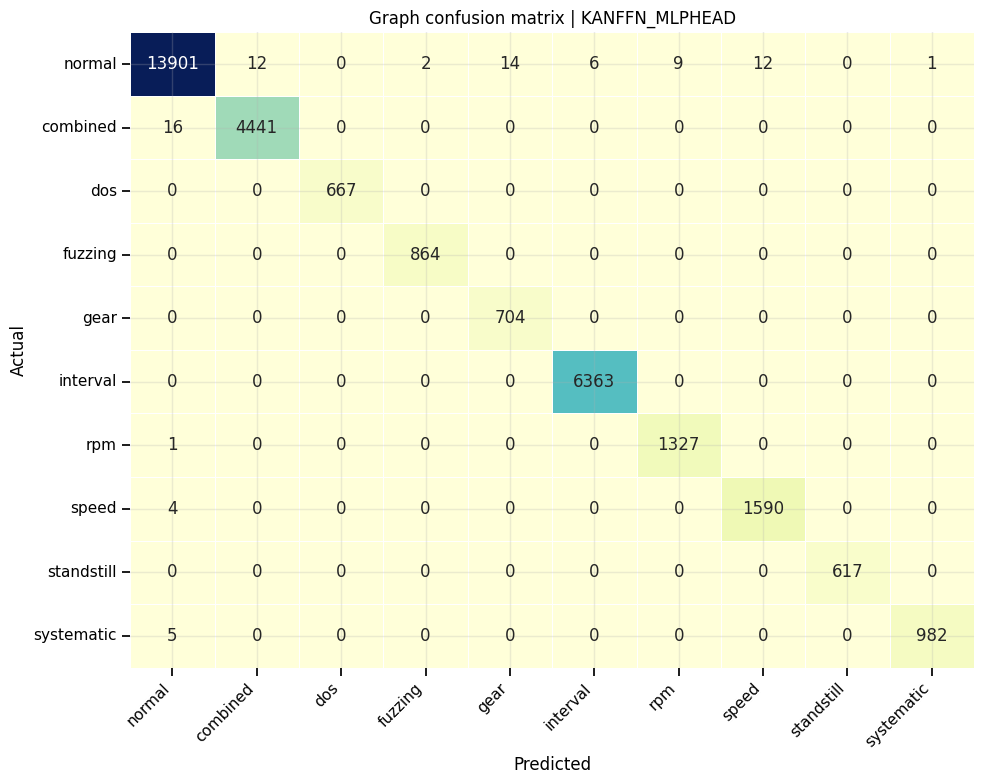

,graph_id,true_label,pred_label,pred_confidence
0,combined__01292416_01292480,combined,normal,1.000000
1,speed__03652928_03652992,speed,normal,1.000000
2,combined__01319360_01319424,combined,normal,0.999997
3,combined__01288384_01288448,combined,normal,0.999973
4,combined__01326144_01326208,combined,normal,0.999949
5,dos__00560448_00560512,normal,fuzzing,0.999932
6,systematic__00317440_00317504,systematic,normal,0.999879
7,systematic__00363840_00363904,systematic,normal,0.999872
8,rpm__01643648_01643712,rpm,normal,0.999495
9,combined__03411136_03411200,normal,combined,0.999280


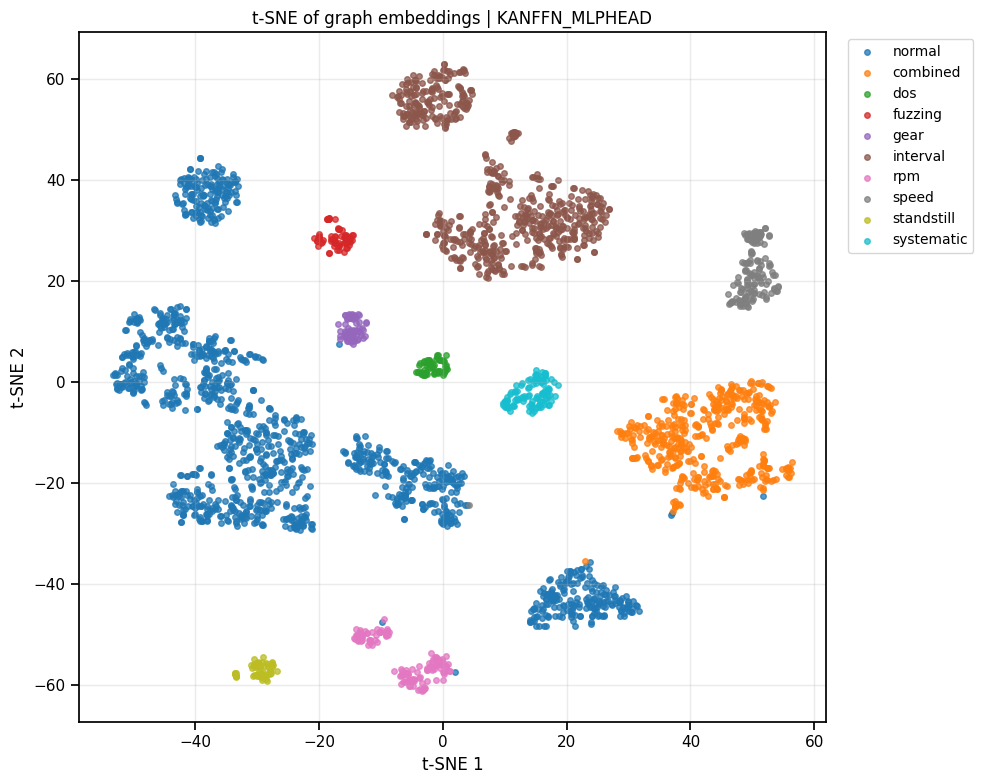

In [9]:

summarize_graph_result(KANFFN_MLPHEAD_RESULTS, 'KANFFN_MLPHEAD')


=== NODE CHECKPOINT | KANFFN_MLPHEAD ===
ACC         : 99.93%
Macro-F1    : 0.9870
Weighted-F1 : 0.9993
Balanced Acc: 0.9923
FNR (%)     : 0.7462%
Samples     : 2018432


,precision,recall,f1-score,support
normal,0.999729,0.999556,0.999643,1.947803e+06
combined,0.970309,0.980200,0.975229,1.697000e+04
dos,0.999707,0.999805,0.999756,1.023200e+04
fuzzing,0.983291,0.988619,0.985948,7.381000e+03
gear,0.924166,1.000000,0.960589,9.140000e+02
interval,0.997825,1.000000,0.998911,2.110200e+04
rpm,0.972714,0.998510,0.985443,3.356000e+03
speed,0.982542,0.987120,0.984826,3.649000e+03
standstill,1.000000,1.000000,1.000000,2.181000e+03
systematic,0.990508,0.969447,0.979864,4.844000e+03


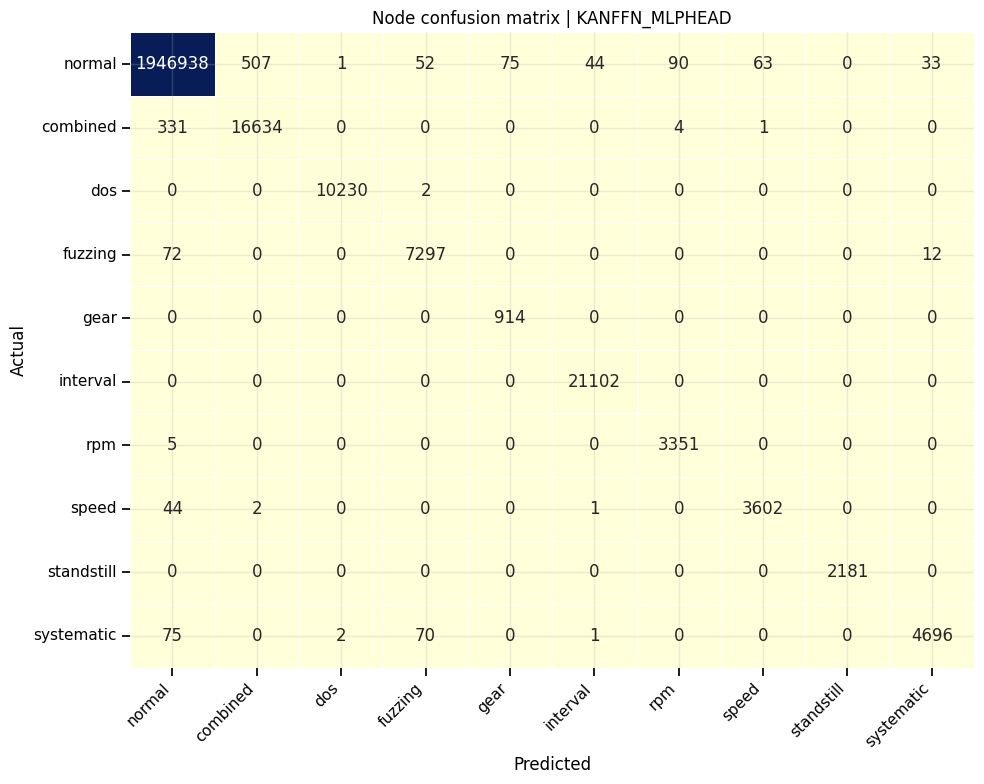

,true_label,pred_label,count
0,normal,combined,507
1,combined,normal,331
2,normal,rpm,90
3,systematic,normal,75
4,normal,gear,75
5,fuzzing,normal,72
6,systematic,fuzzing,70
7,normal,speed,63
8,normal,fuzzing,52
9,normal,interval,44


In [10]:

summarize_node_result(KANFFN_MLPHEAD_RESULTS, 'KANFFN_MLPHEAD')


## 7. Baseline B — MRGAT + MLP FFN + KAN Head

In [12]:

MLPFFN_KANHEAD_RESULTS = run_baseline_pair('MLPFFN_KANHEAD')


MRGAT + MLP FFN + KAN Head
Model module: networks.graph_attention_mlpffn_kanhead_multitask
Graph checkpoint exists: True
Node checkpoint  exists: True
Missing keys   : [] 
Unexpected keys: [] 
Missing keys   : [] 
Unexpected keys: [] 


In [ ]:

summarize_graph_result(MLPFFN_KANHEAD_RESULTS, 'MLPFFN_KANHEAD')


=== NODE CHECKPOINT | MLPFFN_KANHEAD ===
ACC         : 99.83%
Macro-F1    : 0.9665
Weighted-F1 : 0.9983
Balanced Acc: 0.9648
FNR (%)     : 2.0601%
Samples     : 2018432


,precision,recall,f1-score,support
normal,0.999253,0.999176,0.999214,1.947803e+06
combined,0.928474,0.961520,0.944708,1.697000e+04
dos,1.000000,0.999609,0.999804,1.023200e+04
fuzzing,0.963179,0.960439,0.961807,7.381000e+03
gear,0.899371,0.938731,0.918630,9.140000e+02
interval,0.998815,0.998910,0.998863,2.110200e+04
rpm,0.968229,0.917163,0.942005,3.356000e+03
speed,0.954236,0.959989,0.957104,3.649000e+03
standstill,0.997253,0.998624,0.997938,2.181000e+03
systematic,0.978122,0.913708,0.944818,4.844000e+03


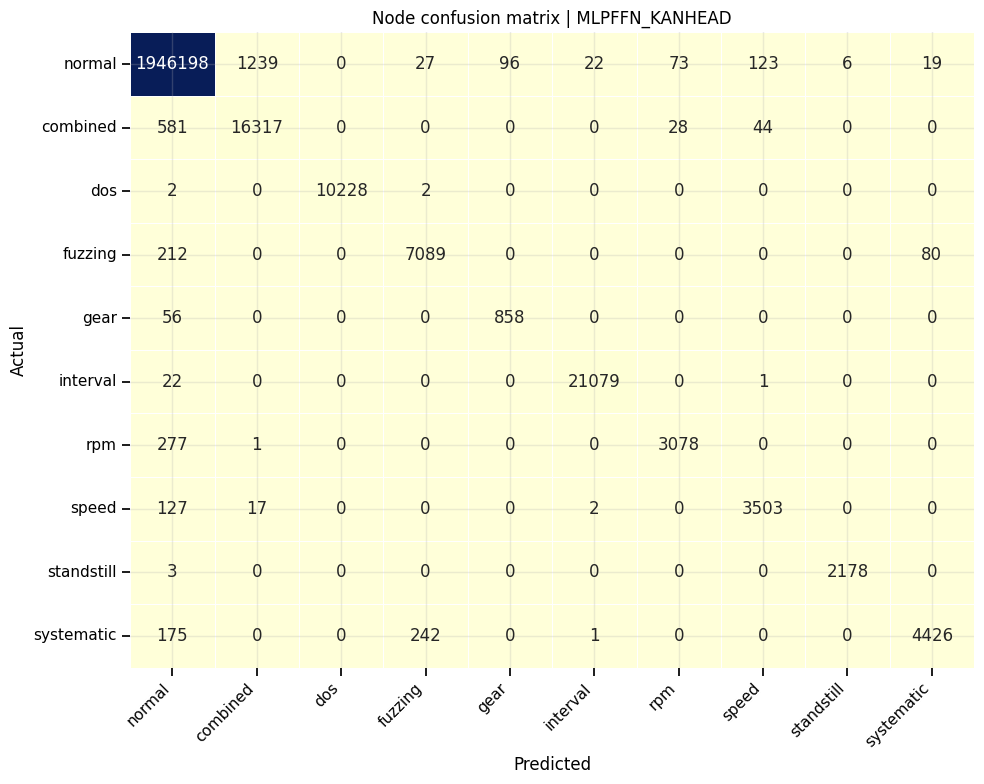

,true_label,pred_label,count
0,normal,combined,1239
1,combined,normal,581
2,rpm,normal,277
3,systematic,fuzzing,242
4,fuzzing,normal,212
5,systematic,normal,175
6,speed,normal,127
7,normal,speed,123
8,normal,gear,96
9,fuzzing,systematic,80


In [13]:

summarize_node_result(MLPFFN_KANHEAD_RESULTS, 'MLPFFN_KANHEAD')


## 8. Baseline C — MRGAT + MLP FFN + MLP Head

In [14]:

MLPFFN_MLPHEAD_RESULTS = run_baseline_pair('MLPFFN_MLPHEAD')


MRGAT + MLP FFN + MLP Head
Model module: networks.graph_attention_mlpffn_mlphead_multitask
Graph checkpoint exists: True
Node checkpoint  exists: True
Missing keys   : [] 
Unexpected keys: [] 
Missing keys   : [] 
Unexpected keys: [] 


In [ ]:

summarize_graph_result(MLPFFN_MLPHEAD_RESULTS, 'MLPFFN_MLPHEAD')


=== NODE CHECKPOINT | MLPFFN_MLPHEAD ===
ACC         : 99.75%
Macro-F1    : 0.9345
Weighted-F1 : 0.9975
Balanced Acc: 0.9514
FNR (%)     : 2.4480%
Samples     : 2018432


,precision,recall,f1-score,support
normal,0.999112,0.998757,0.998935,1.947803e+06
combined,0.929641,0.954567,0.941939,1.697000e+04
dos,0.999902,0.999511,0.999707,1.023200e+04
fuzzing,0.899308,0.968026,0.932402,7.381000e+03
gear,0.635154,0.992341,0.774552,9.140000e+02
interval,0.989913,0.999858,0.994860,2.110200e+04
rpm,0.966308,0.828963,0.892382,3.356000e+03
speed,0.898874,0.962181,0.929451,3.649000e+03
standstill,0.983762,1.000000,0.991814,2.181000e+03
systematic,0.985423,0.809455,0.888813,4.844000e+03


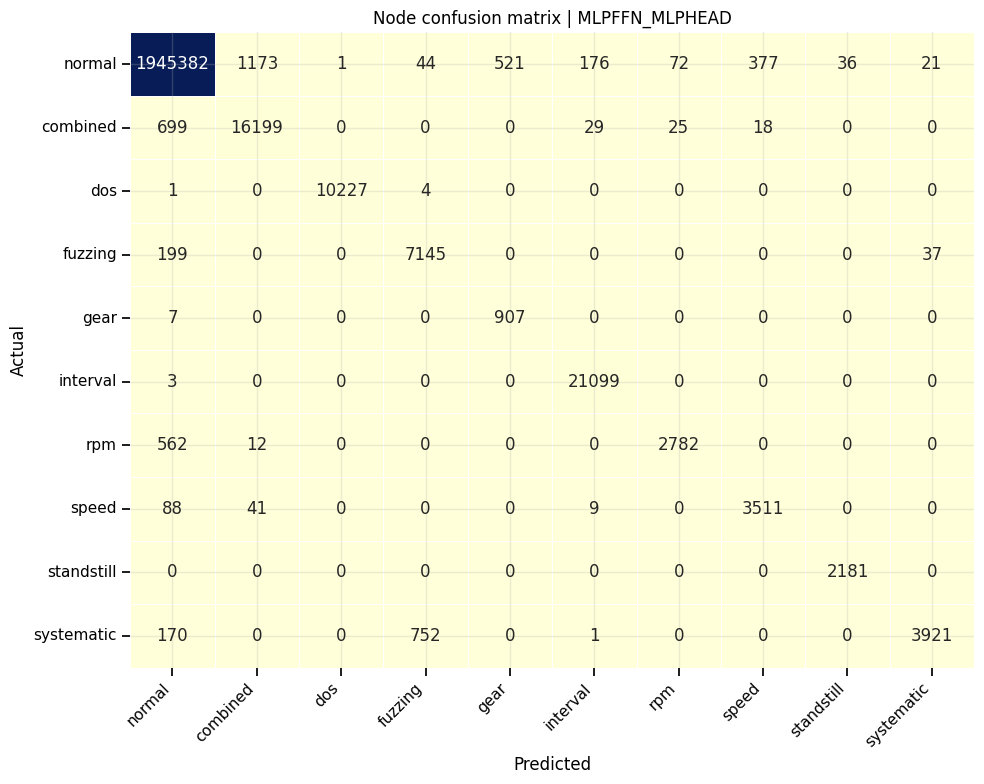

,true_label,pred_label,count
0,normal,combined,1173
1,systematic,fuzzing,752
2,combined,normal,699
3,rpm,normal,562
4,normal,gear,521
5,normal,speed,377
6,fuzzing,normal,199
7,normal,interval,176
8,systematic,normal,170
9,speed,normal,88


In [15]:

summarize_node_result(MLPFFN_MLPHEAD_RESULTS, 'MLPFFN_MLPHEAD')
